# Noise floor + coarse full-trace sweep (2.5-3.0 GHz, 100 MHz steps)

Two things:
1. Measure the E4403B's own noise floor (generator RF output off, nothing driving the analyzer input).
2. Step the HP8673H's CW frequency in 100 MHz increments and, at each step, capture the analyzer's *full* trace (not just a single marker point) -- this shows the tone, its skirt, and the surrounding noise floor at every step.

Output power kept low (-20 dBm at the generator) throughout.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from hp8673h import HP8673H
from e4403b import E4403B
from frequency_sweep import frequency_sweep_full_trace, concatenate_traces

In [2]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")

START_HZ = 2.5e9
STOP_HZ = 3.0e9
STEP_HZ = 100e6

HP8673H: connected
E4403B: connected


## 1. Analyzer noise floor (generator RF off)

In [3]:
gen.preset()
gen.rf_off()

sa.write("TRAC1:MODE WRITE")
sa.write("AVER:STATE OFF")
sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)
sa.write("INIT:CONT OFF")
sa.write("INIT:IMM")
sa.query("*OPC?")

noise_freqs, noise_power = sa.get_trace(1)
rbw = sa.query("BAND?")
atten = sa.query("POW:ATT?")
noise_floor_dbm = np.median(noise_power)

print(f"RBW: {rbw} Hz, input attenuation: {atten} dB")
print(f"noise floor (median, RF off): {noise_floor_dbm:.1f} dBm")
print(f"range: {noise_power.min():.1f} to {noise_power.max():.1f} dBm")

RBW: +1.00000000E+006 Hz, input attenuation: +1.000E+01 dB
noise floor (median, RF off): -64.2 dBm
range: -67.8 to -60.4 dBm


## 2. Full-trace sweep, 100 MHz steps

In [4]:
traces = frequency_sweep_full_trace(
    gen, sa,
    start_hz=START_HZ, stop_hz=STOP_HZ, step_hz=STEP_HZ,
    power_dbm=-20,
)

freqs_hz, power_dbm = concatenate_traces(traces)

gen.close()
sa.close()

print(f"{len(traces)} windows, {len(freqs_hz)} total points")

6 windows, 2406 total points


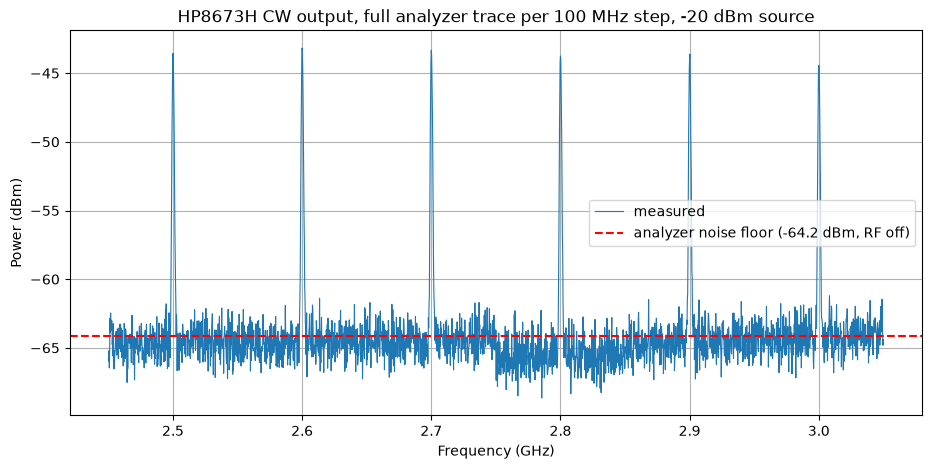

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(freqs_hz / 1e9, power_dbm, linewidth=0.8, label="measured")
ax.axhline(noise_floor_dbm, color='r', linestyle='--',
           label=f"analyzer noise floor ({noise_floor_dbm:.1f} dBm, RF off)")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Power (dBm)")
ax.set_title("HP8673H CW output, full analyzer trace per 100 MHz step, -20 dBm source")
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
data = np.column_stack((freqs_hz, power_dbm))
np.savetxt(
    "data/full_trace_sweep_2.5-3.0GHz_100MHz-steps.csv",
    data,
    delimiter=",",
    header="frequency_hz,power_dbm",
    comments="",
)